# Análisis de Ángulos Diedros — Simulación de Dinámica Molecular

**Sistema:** Tripéptido **ACE-ALA-ARG-VAL-NME** (ARV) en solución acuosa  
**Campo de fuerzas:** CHARMM27 · **Modelo de agua:** TIP3P  
**Herramienta:** GROMACS · `gmx rama`  
**Temperaturas simuladas:** 298 K y 400 K

**Residuos seleccionados para análisis detallado:**

| Residuo | Posición | Naturaleza | Relevancia |
|---|---|---|---|
| `ALA-2` | Central | No polar, alifático (cadena lateral −CH₃) | Referencia estructural; ángulos diedros bien definidos |
| `ARG-3` | C-terminal | Polar, cargado positivo (+) a pH fisiológico | Alta movilidad conformacional; interacciones electrostáticas |

> VAL-4 (residuo N-terminal del extremo C) también se incluye en los diagramas de Ramachandran como referencia del tripéptido completo.

**Datos de partida generados con GROMACS:**
- `rama-{T}.xvg` — salida de `gmx rama`: φ y ψ de cada residuo en cada frame a temperatura T
- `phi/psi-{RES}-{T}.dat` — series temporales individuales (frame, ángulo en °) extraídas del `.xvg`
- `{RES}-{T}.dat` — fichero `join` con φ y ψ combinados por residuo y temperatura

Los ángulos φ y ψ definen la conformación del esqueleto proteico y se representan en el **diagrama de Ramachandran** (φ, ψ ∈ [−180°, 180°]).

---

## 1. Importación de librerías y configuración de estilo

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import sem, gaussian_kde
from scipy.ndimage import gaussian_filter

# ── Estilo publicación científica ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family':         'serif',
    'font.size':           11,
    'axes.labelsize':      12,
    'axes.titlesize':      12,
    'axes.linewidth':      1.2,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.major.width':   1.1,
    'ytick.major.width':   1.1,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'legend.framealpha':   0.9,
    'legend.fontsize':     10,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
})

# Timestep del output de la simulación (ps)
DT_PS = 0.001  # 1 fs


def mask_wraparound(series, threshold=170):
    """Inserta NaN donde el ángulo diedro cruza la frontera ±180°.
    Evita las líneas verticales espurias en las series temporales.
    """
    arr = series.values.astype(float).copy()
    jumps = np.abs(np.diff(arr)) > threshold
    arr[1:][jumps] = np.nan
    return arr


def unwrap_deg(angles_deg):
    """Desenvuelve ángulos en grados para series temporales continuas.
    Elimina las discontinuidades en ±180° añadiendo ±360° según sea necesario.
    """
    return np.degrees(np.unwrap(np.radians(angles_deg)))


def circ_mean_deg(angles_deg):
    """Media circular de ángulos en grados."""
    r = np.radians(angles_deg)
    return np.degrees(np.arctan2(np.sin(r).mean(), np.cos(r).mean()))


def circ_std_deg(angles_deg):
    """Desviación estándar circular de ángulos en grados."""
    r = np.radians(angles_deg)
    R = np.hypot(np.sin(r).mean(), np.cos(r).mean())
    return np.degrees(np.sqrt(max(0, -2 * np.log(R))))


print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga de datos

In [14]:
def load_dat(filepath):
    """Lee un archivo .dat con columnas [frame_idx, phi, psi] y asigna tiempo en ps."""
    df = pd.read_csv(filepath, sep=r'\s+', header=None, names=['frame', 'phi', 'psi'])
    df['time_ps'] = (df['frame'] - 1) * DT_PS
    return df[['time_ps', 'phi', 'psi']]


def parse_rama_xvg(filepath):
    """Lee rama.xvg de GROMACS y devuelve un dict {residue_name: DataFrame(time_ps, phi, psi)}.
    Cada trío de líneas consecutivas corresponde a un frame (ALA-2, ARG-3, VAL-4).
    """
    entries = {res: [] for res in ['ALA-2', 'ARG-3', 'VAL-4']}
    with open(filepath) as fh:
        frame = 0
        buffer = {}
        for line in fh:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) == 3:
                phi_val, psi_val, res = float(parts[0]), float(parts[1]), parts[2]
                buffer[res] = (phi_val, psi_val)
                if len(buffer) == 3:
                    t = frame * DT_PS
                    for res_name, (phi_v, psi_v) in buffer.items():
                        entries[res_name].append({'time_ps': t, 'phi': phi_v, 'psi': psi_v})
                    buffer = {}
                    frame += 1
    return {res: pd.DataFrame(rows) for res, rows in entries.items()}


DIHEDRAL_DIR = ''

# ── Cargar series temporales desde archivos .dat ───────────────────────────────
df_ALA2_298 = load_dat(DIHEDRAL_DIR + 'ALA-2-298.dat')
df_ALA2_400 = load_dat(DIHEDRAL_DIR + 'ALA-2-400.dat')
df_ARG3_298 = load_dat(DIHEDRAL_DIR + 'ARG-3-298.dat')
df_ARG3_400 = load_dat(DIHEDRAL_DIR + 'ARG-3-400.dat')

# ── Parsear rama.xvg para tener también VAL-4 ────────────────────────────────
rama_298 = parse_rama_xvg(DIHEDRAL_DIR + 'rama-298.xvg')
rama_400 = parse_rama_xvg(DIHEDRAL_DIR + 'rama-400.xvg')
df_VAL4_298 = rama_298['VAL-4']
df_VAL4_400 = rama_400['VAL-4']

for label, df in [
        ('ALA-2 298 K', df_ALA2_298), ('ALA-2 400 K', df_ALA2_400),
        ('ARG-3 298 K', df_ARG3_298), ('ARG-3 400 K', df_ARG3_400),
        ('VAL-4 298 K', df_VAL4_298), ('VAL-4 400 K', df_VAL4_400),
]:
    print(f'{label}: {len(df):4d} frames | '
          f't = {df.time_ps.min():.3f} – {df.time_ps.max():.3f} ps | '
          f'φ = {df.phi.min():.1f}° – {df.phi.max():.1f}° | '
          f'ψ = {df.psi.min():.1f}° – {df.psi.max():.1f}°')


ALA-2 298 K: 2001 frames | t = 0.000 – 2.000 ps | φ = -106.7° – -39.1° | ψ = -179.9° – 180.0°
ALA-2 400 K: 2001 frames | t = 0.000 – 2.000 ps | φ = -101.6° – -30.1° | ψ = 117.7° – 159.6°
ARG-3 298 K: 2001 frames | t = 0.000 – 2.000 ps | φ = -75.0° – -23.6° | ψ = 116.2° – 154.0°
ARG-3 400 K: 2001 frames | t = 0.000 – 2.000 ps | φ = 32.4° – 84.0° | ψ = -179.8° – 179.9°
VAL-4 298 K: 2001 frames | t = 0.000 – 2.000 ps | φ = -107.7° – -61.5° | ψ = 79.6° – 125.9°
VAL-4 400 K: 2001 frames | t = 0.000 – 2.000 ps | φ = -138.8° – -46.0° | ψ = -180.0° – 179.9°


## 3. Evolución temporal — ALA-2: φ y ψ

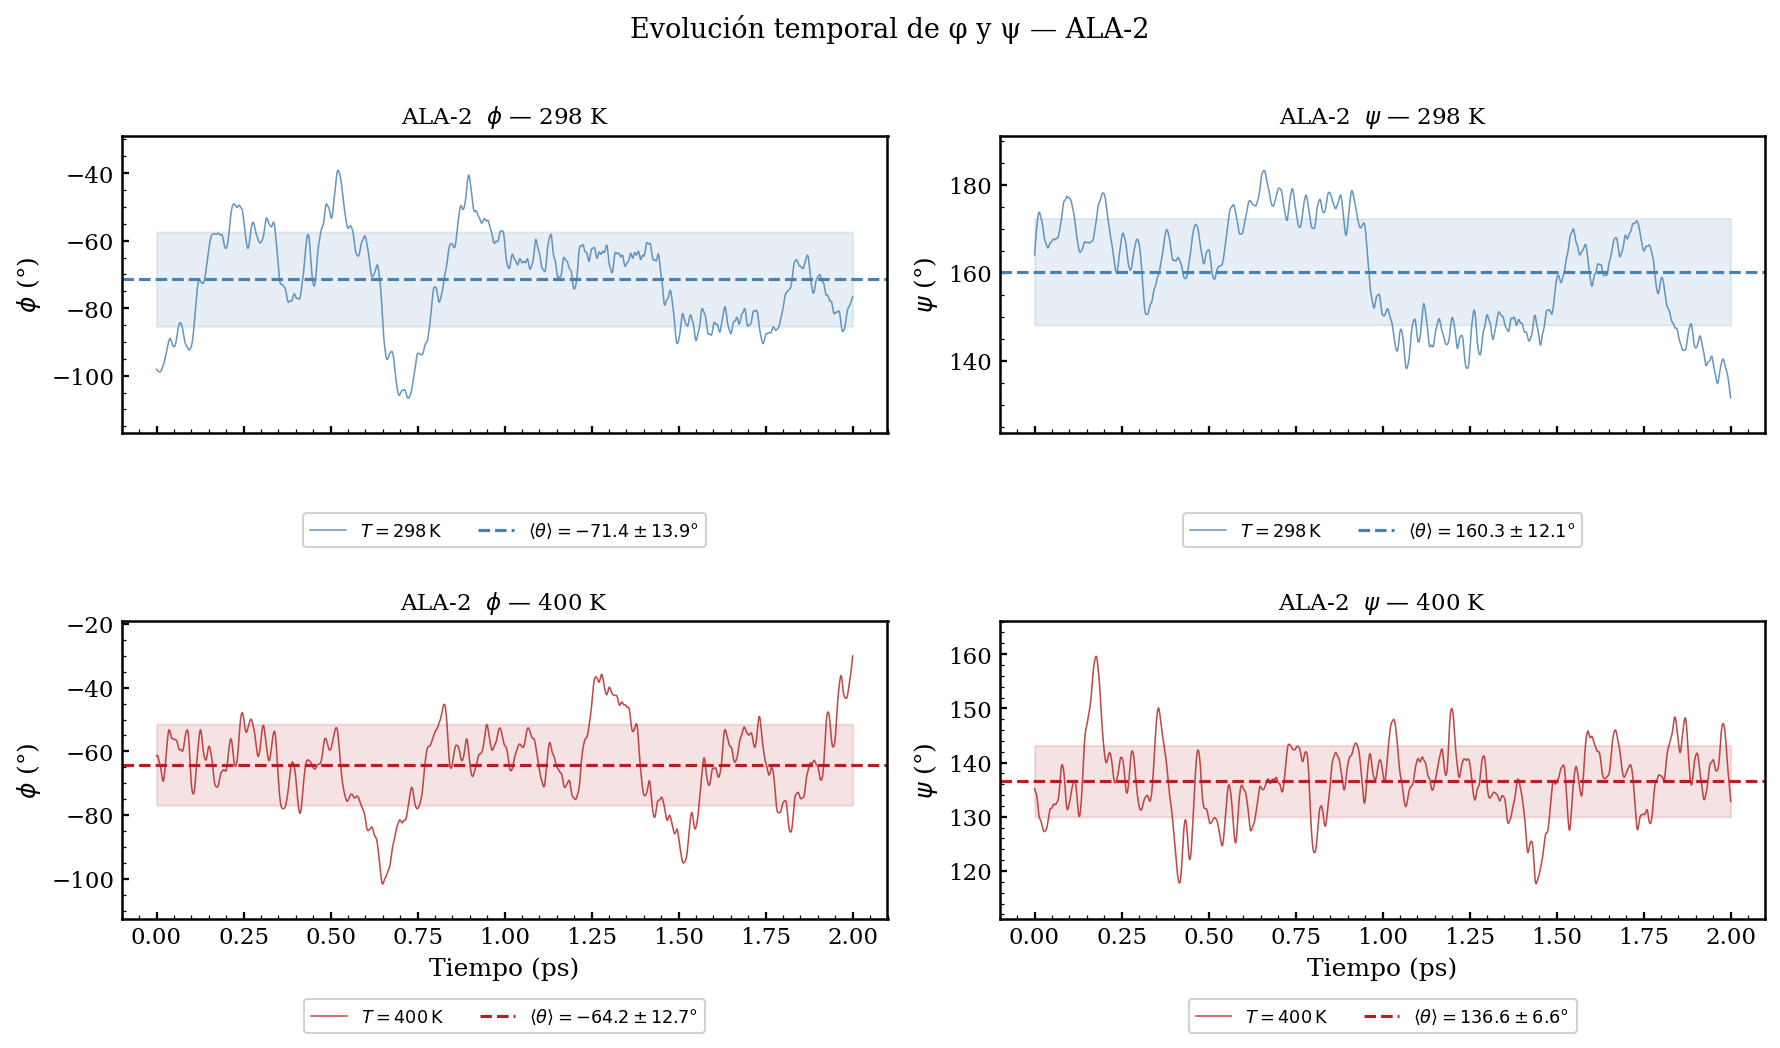

Figura guardada como dihedral_timeseries_ALA2.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

for col_ax, (angle_key, angle_label) in enumerate([('phi', r'$\phi$'), ('psi', r'$\psi$')]):
    for row_ax, (df, T, color) in enumerate([(df_ALA2_298, 298, 'steelblue'),
                                              (df_ALA2_400, 400, 'firebrick')]):
        ax = axes[row_ax, col_ax]
        y_uw = unwrap_deg(df[angle_key].values)
        mu  = y_uw.mean()
        sig = y_uw.std()

        ax.plot(df['time_ps'], y_uw,
                color=color, lw=0.75, alpha=0.82,
                label=rf'$T = {T}\,\mathrm{{K}}$')
        ax.axhline(mu, color=color, lw=1.5, ls='--',
                   label=rf'$\langle\theta\rangle = {mu:.1f} \pm {sig:.1f}$°')
        ax.fill_between(df['time_ps'], mu - sig, mu + sig,
                        color=color, alpha=0.13)

        pad = 0.15 * (y_uw.max() - y_uw.min() + 1)
        ax.set_ylim(y_uw.min() - pad, y_uw.max() + pad)

        ax.set_ylabel(rf'{angle_label} (°)')
        ax.set_title(f'ALA-2  {angle_label} — {T} K', fontsize=11)
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=2, fontsize=8.5)

for ax in axes[-1]:
    ax.set_xlabel('Tiempo (ps)')

fig.suptitle('Evolución temporal de φ y ψ — ALA-2', fontsize=13, y=1.01)
fig.align_ylabels()
plt.tight_layout()
plt.savefig('dihedral_timeseries_ALA2.png')
plt.show()
print('Figura guardada como dihedral_timeseries_ALA2.png')

## 4. Evolución temporal — ARG-3: φ y ψ

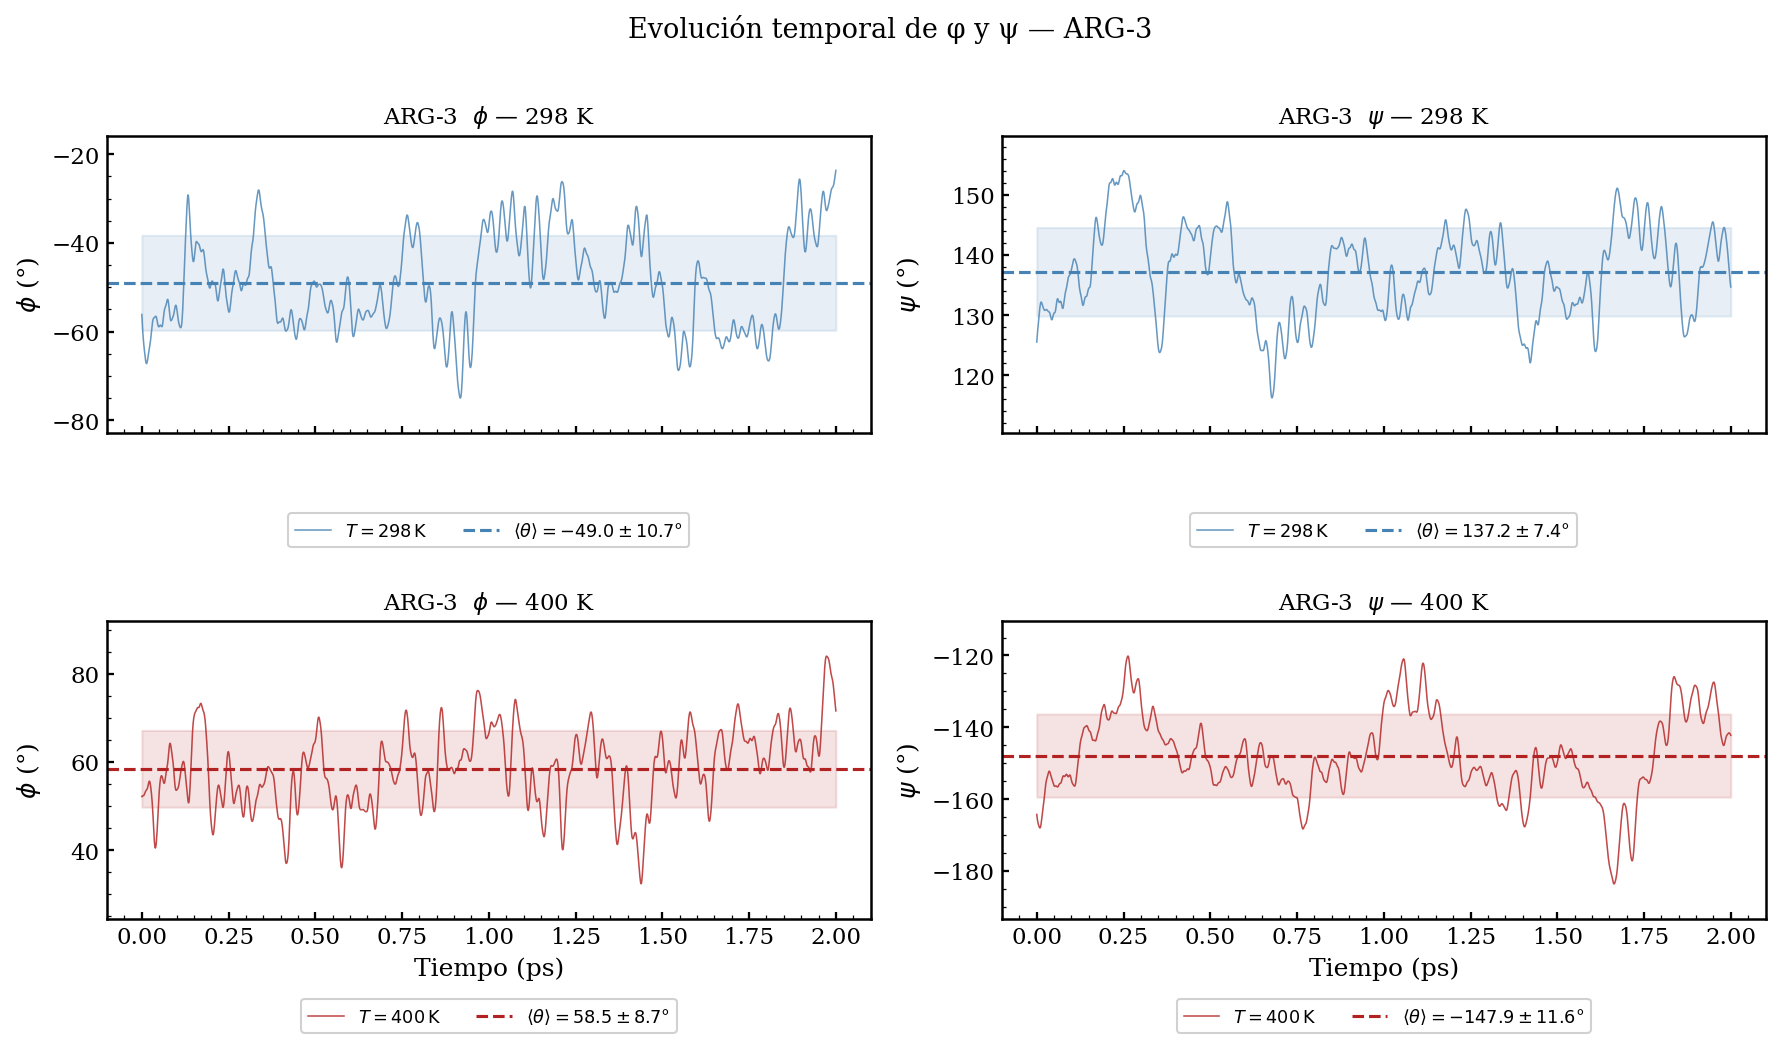

Figura guardada como dihedral_timeseries_ARG3.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

for col_ax, (angle_key, angle_label) in enumerate([('phi', r'$\phi$'), ('psi', r'$\psi$')]):
    for row_ax, (df, T, color) in enumerate([(df_ARG3_298, 298, 'steelblue'),
                                              (df_ARG3_400, 400, 'firebrick')]):
        ax = axes[row_ax, col_ax]
        y_uw = unwrap_deg(df[angle_key].values)
        mu  = y_uw.mean()
        sig = y_uw.std()

        ax.plot(df['time_ps'], y_uw,
                color=color, lw=0.75, alpha=0.82,
                label=rf'$T = {T}\,\mathrm{{K}}$')
        ax.axhline(mu, color=color, lw=1.5, ls='--',
                   label=rf'$\langle\theta\rangle = {mu:.1f} \pm {sig:.1f}$°')
        ax.fill_between(df['time_ps'], mu - sig, mu + sig,
                        color=color, alpha=0.13)

        pad = 0.15 * (y_uw.max() - y_uw.min() + 1)
        ax.set_ylim(y_uw.min() - pad, y_uw.max() + pad)

        ax.set_ylabel(rf'{angle_label} (°)')
        ax.set_title(f'ARG-3  {angle_label} — {T} K', fontsize=11)
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=2, fontsize=8.5)

for ax in axes[-1]:
    ax.set_xlabel('Tiempo (ps)')

fig.suptitle('Evolución temporal de φ y ψ — ARG-3', fontsize=13, y=1.01)
fig.align_ylabels()
plt.tight_layout()
plt.savefig('dihedral_timeseries_ARG3.png')
plt.show()
print('Figura guardada como dihedral_timeseries_ARG3.png')

## 5. Comparación directa — evolución temporal de φ y ψ (todos los residuos)

Se representan las cuatro series (ALA-2 y ARG-3 a 298 K y 400 K) en un mismo panel para cada ángulo diedro, facilitando la comparación directa del rango conformacional explorado.

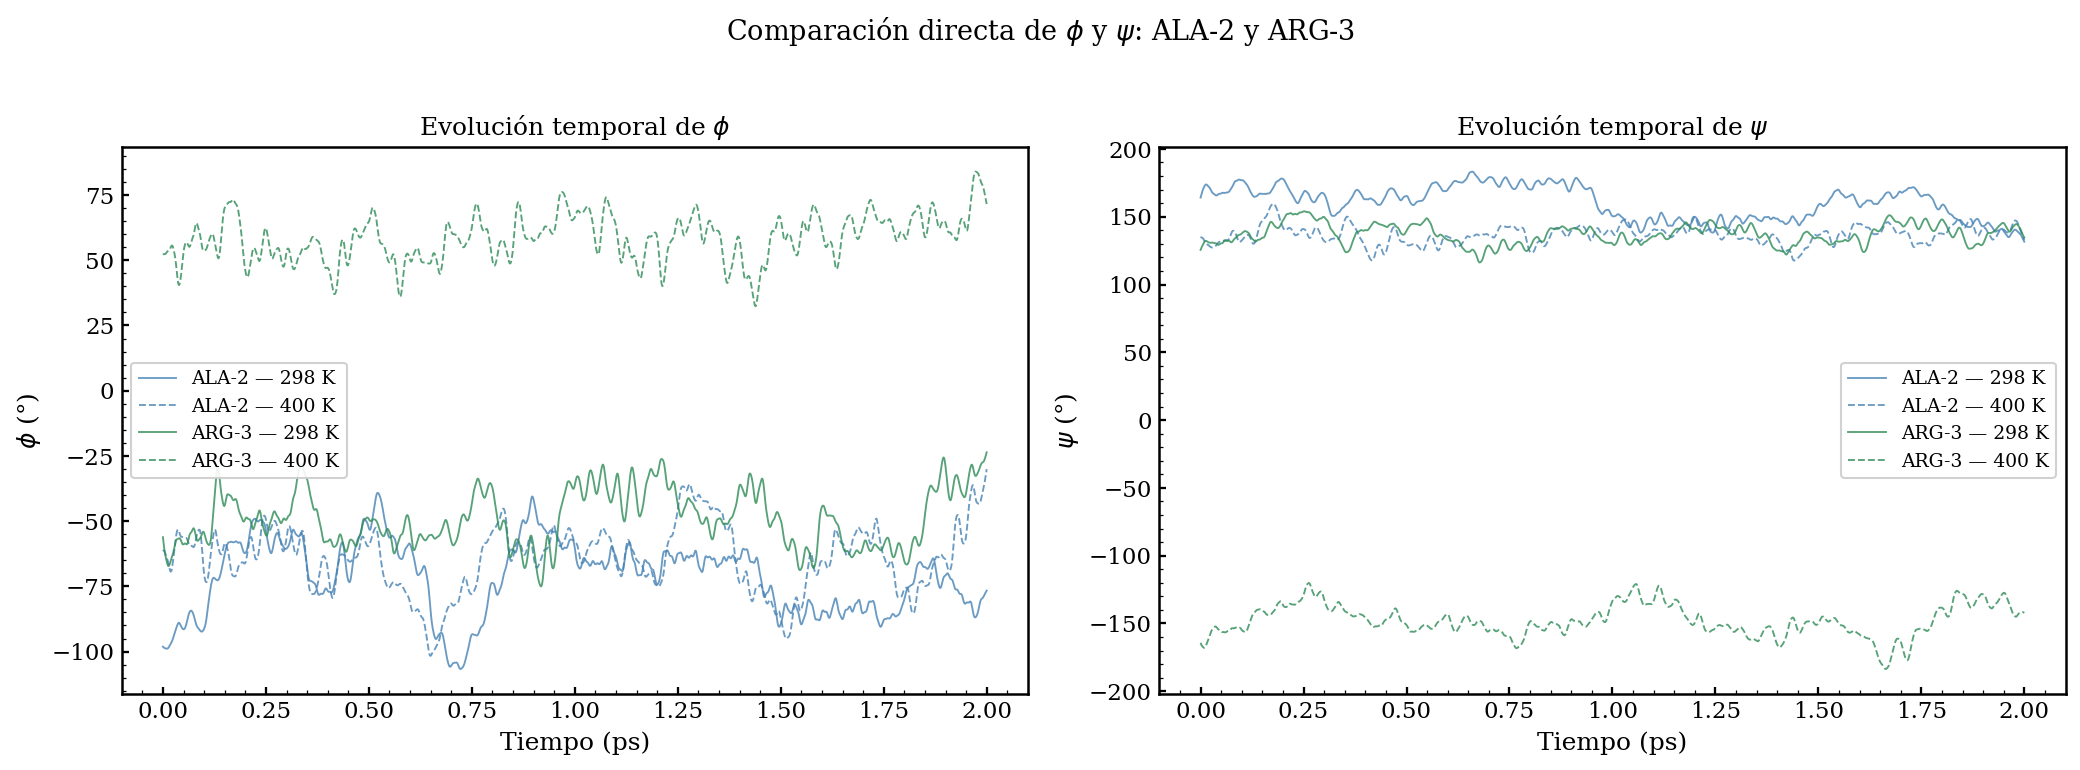

Figura guardada como dihedral_comparison_phi_psi.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

configs = [
    (df_ALA2_298, 'ALA-2', 298, 'steelblue', '-'),
    (df_ALA2_400, 'ALA-2', 400, 'steelblue', '--'),
    (df_ARG3_298, 'ARG-3', 298, 'seagreen',  '-'),
    (df_ARG3_400, 'ARG-3', 400, 'seagreen',  '--'),
]

for ax, (angle_key, angle_label) in zip(axes, [('phi', r'$\phi$'), ('psi', r'$\psi$')]):
    for df, res, T, color, ls in configs:
        y = unwrap_deg(df[angle_key].values)
        ax.plot(df['time_ps'], y, color=color, ls=ls, lw=0.9, alpha=0.80,
                label=rf'{res} — {T} K')
    ax.set_xlabel('Tiempo (ps)')
    ax.set_ylabel(rf'{angle_label} (°)')
    ax.set_title(rf'Evolución temporal de {angle_label}', fontsize=12)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.legend(fontsize=9)

fig.suptitle(r'Comparación directa de $\phi$ y $\psi$: ALA-2 y ARG-3', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('dihedral_comparison_phi_psi.png')
plt.show()
print('Figura guardada como dihedral_comparison_phi_psi.png')

## 6. Superposición por residuo — efecto de la temperatura

Cada panel muestra un ángulo diedro (φ o ψ) con las dos temperaturas superpuestas, lo que permite visualizar directamente el efecto térmico sobre la dinámica conformacional de cada residuo.

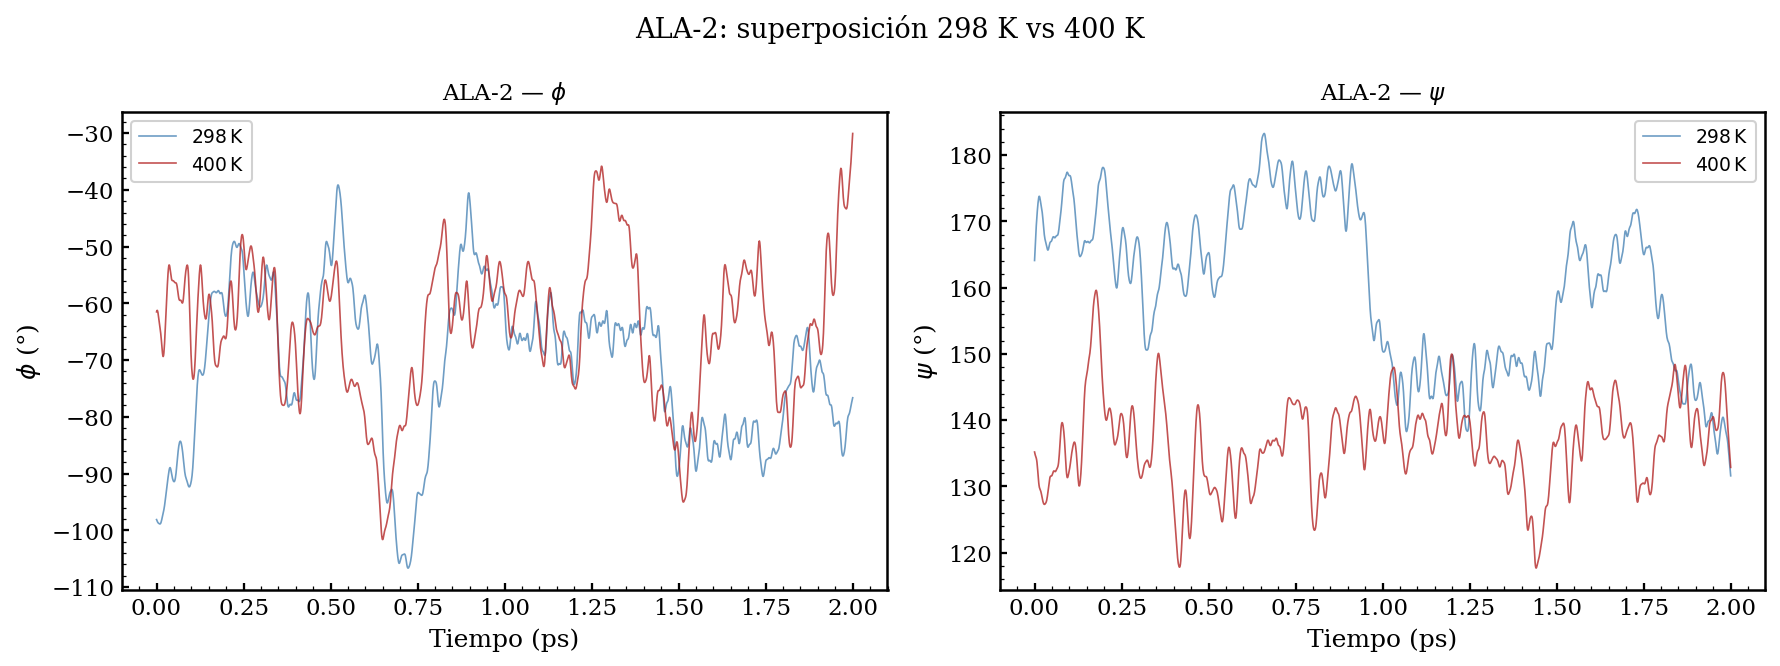

Figura guardada como dihedral_overlay_ALA2.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (angle_key, angle_label) in zip(axes, [('phi', r'$\phi$'), ('psi', r'$\psi$')]):
    for df, T, color in [(df_ALA2_298, 298, 'steelblue'),
                          (df_ALA2_400, 400, 'firebrick')]:
        y = unwrap_deg(df[angle_key].values)
        ax.plot(df['time_ps'], y, color=color, lw=0.8, alpha=0.78,
                label=rf'${T}\,\mathrm{{K}}$')
    ax.set_xlabel('Tiempo (ps)')
    ax.set_ylabel(rf'{angle_label} (°)')
    ax.set_title(rf'ALA-2 — {angle_label}', fontsize=11)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.legend(fontsize=9)

fig.suptitle('ALA-2: superposición 298 K vs 400 K', fontsize=13)
plt.tight_layout()
plt.savefig('dihedral_overlay_ALA2.png')
plt.show()
print('Figura guardada como dihedral_overlay_ALA2.png')

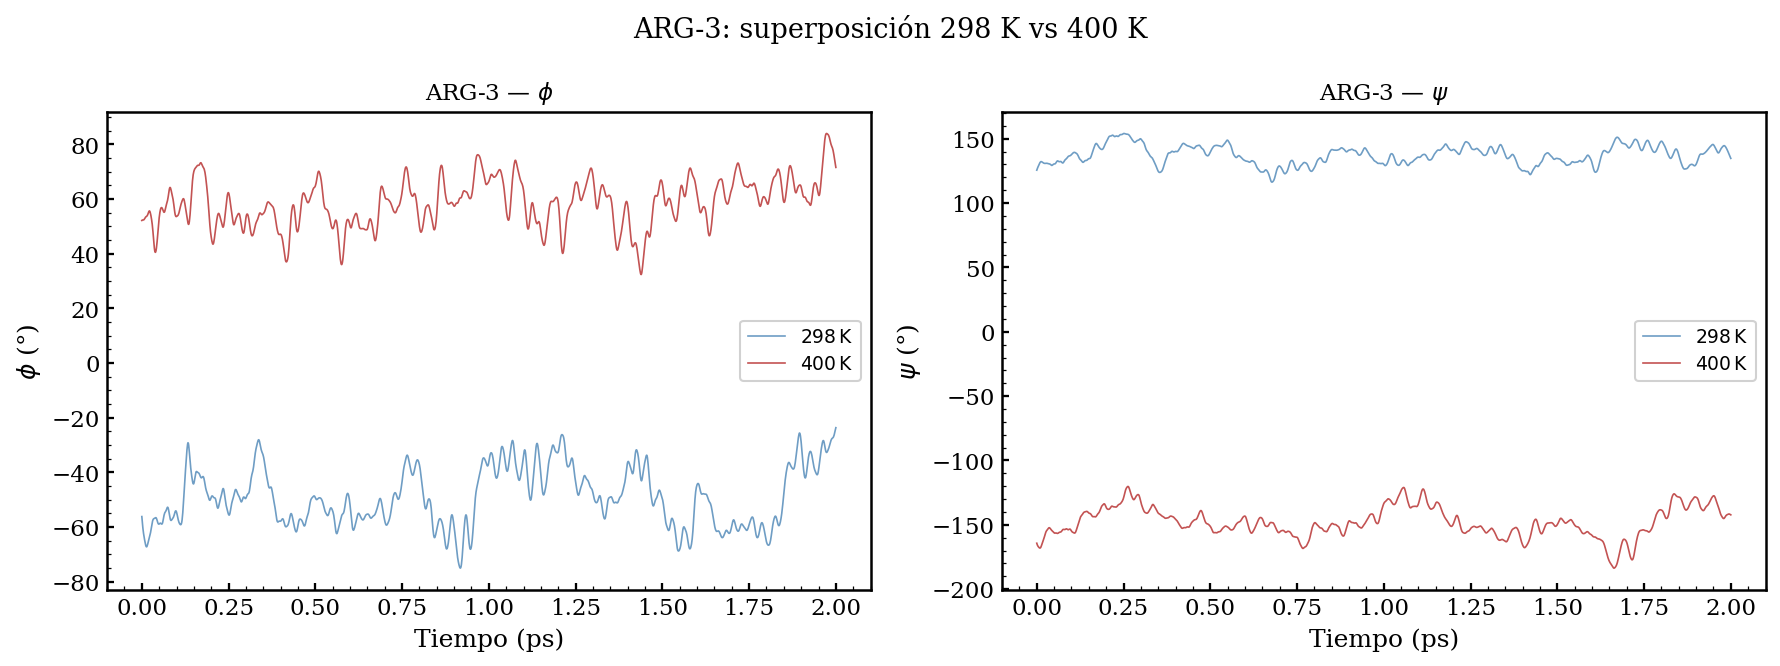

Figura guardada como dihedral_overlay_ARG3.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (angle_key, angle_label) in zip(axes, [('phi', r'$\phi$'), ('psi', r'$\psi$')]):
    for df, T, color in [(df_ARG3_298, 298, 'steelblue'),
                          (df_ARG3_400, 400, 'firebrick')]:
        y = unwrap_deg(df[angle_key].values)
        ax.plot(df['time_ps'], y, color=color, lw=0.8, alpha=0.78,
                label=rf'${T}\,\mathrm{{K}}$')
    ax.set_xlabel('Tiempo (ps)')
    ax.set_ylabel(rf'{angle_label} (°)')
    ax.set_title(rf'ARG-3 — {angle_label}', fontsize=11)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.legend(fontsize=9)

fig.suptitle('ARG-3: superposición 298 K vs 400 K', fontsize=13)
plt.tight_layout()
plt.savefig('dihedral_overlay_ARG3.png')
plt.show()
print('Figura guardada como dihedral_overlay_ARG3.png')

## 8. Diagrama de Ramachandran — 298 K vs 400 K por residuo

El diagrama de Ramachandran muestra las combinaciones (φ, ψ) accesibles para cada residuo.  
Las regiones de mayor densidad indican conformaciones estables:

| Región | φ (°) | ψ (°) | Conformación |
|---|---|---|---|
| αR | −60 | −45 | Hélice α derecha |
| β | −120 | +140 | Lámina β |
| αL | +60 | +45 | Hélice α izquierda |
| PPII | −75 | +150 | Poliprolina II |

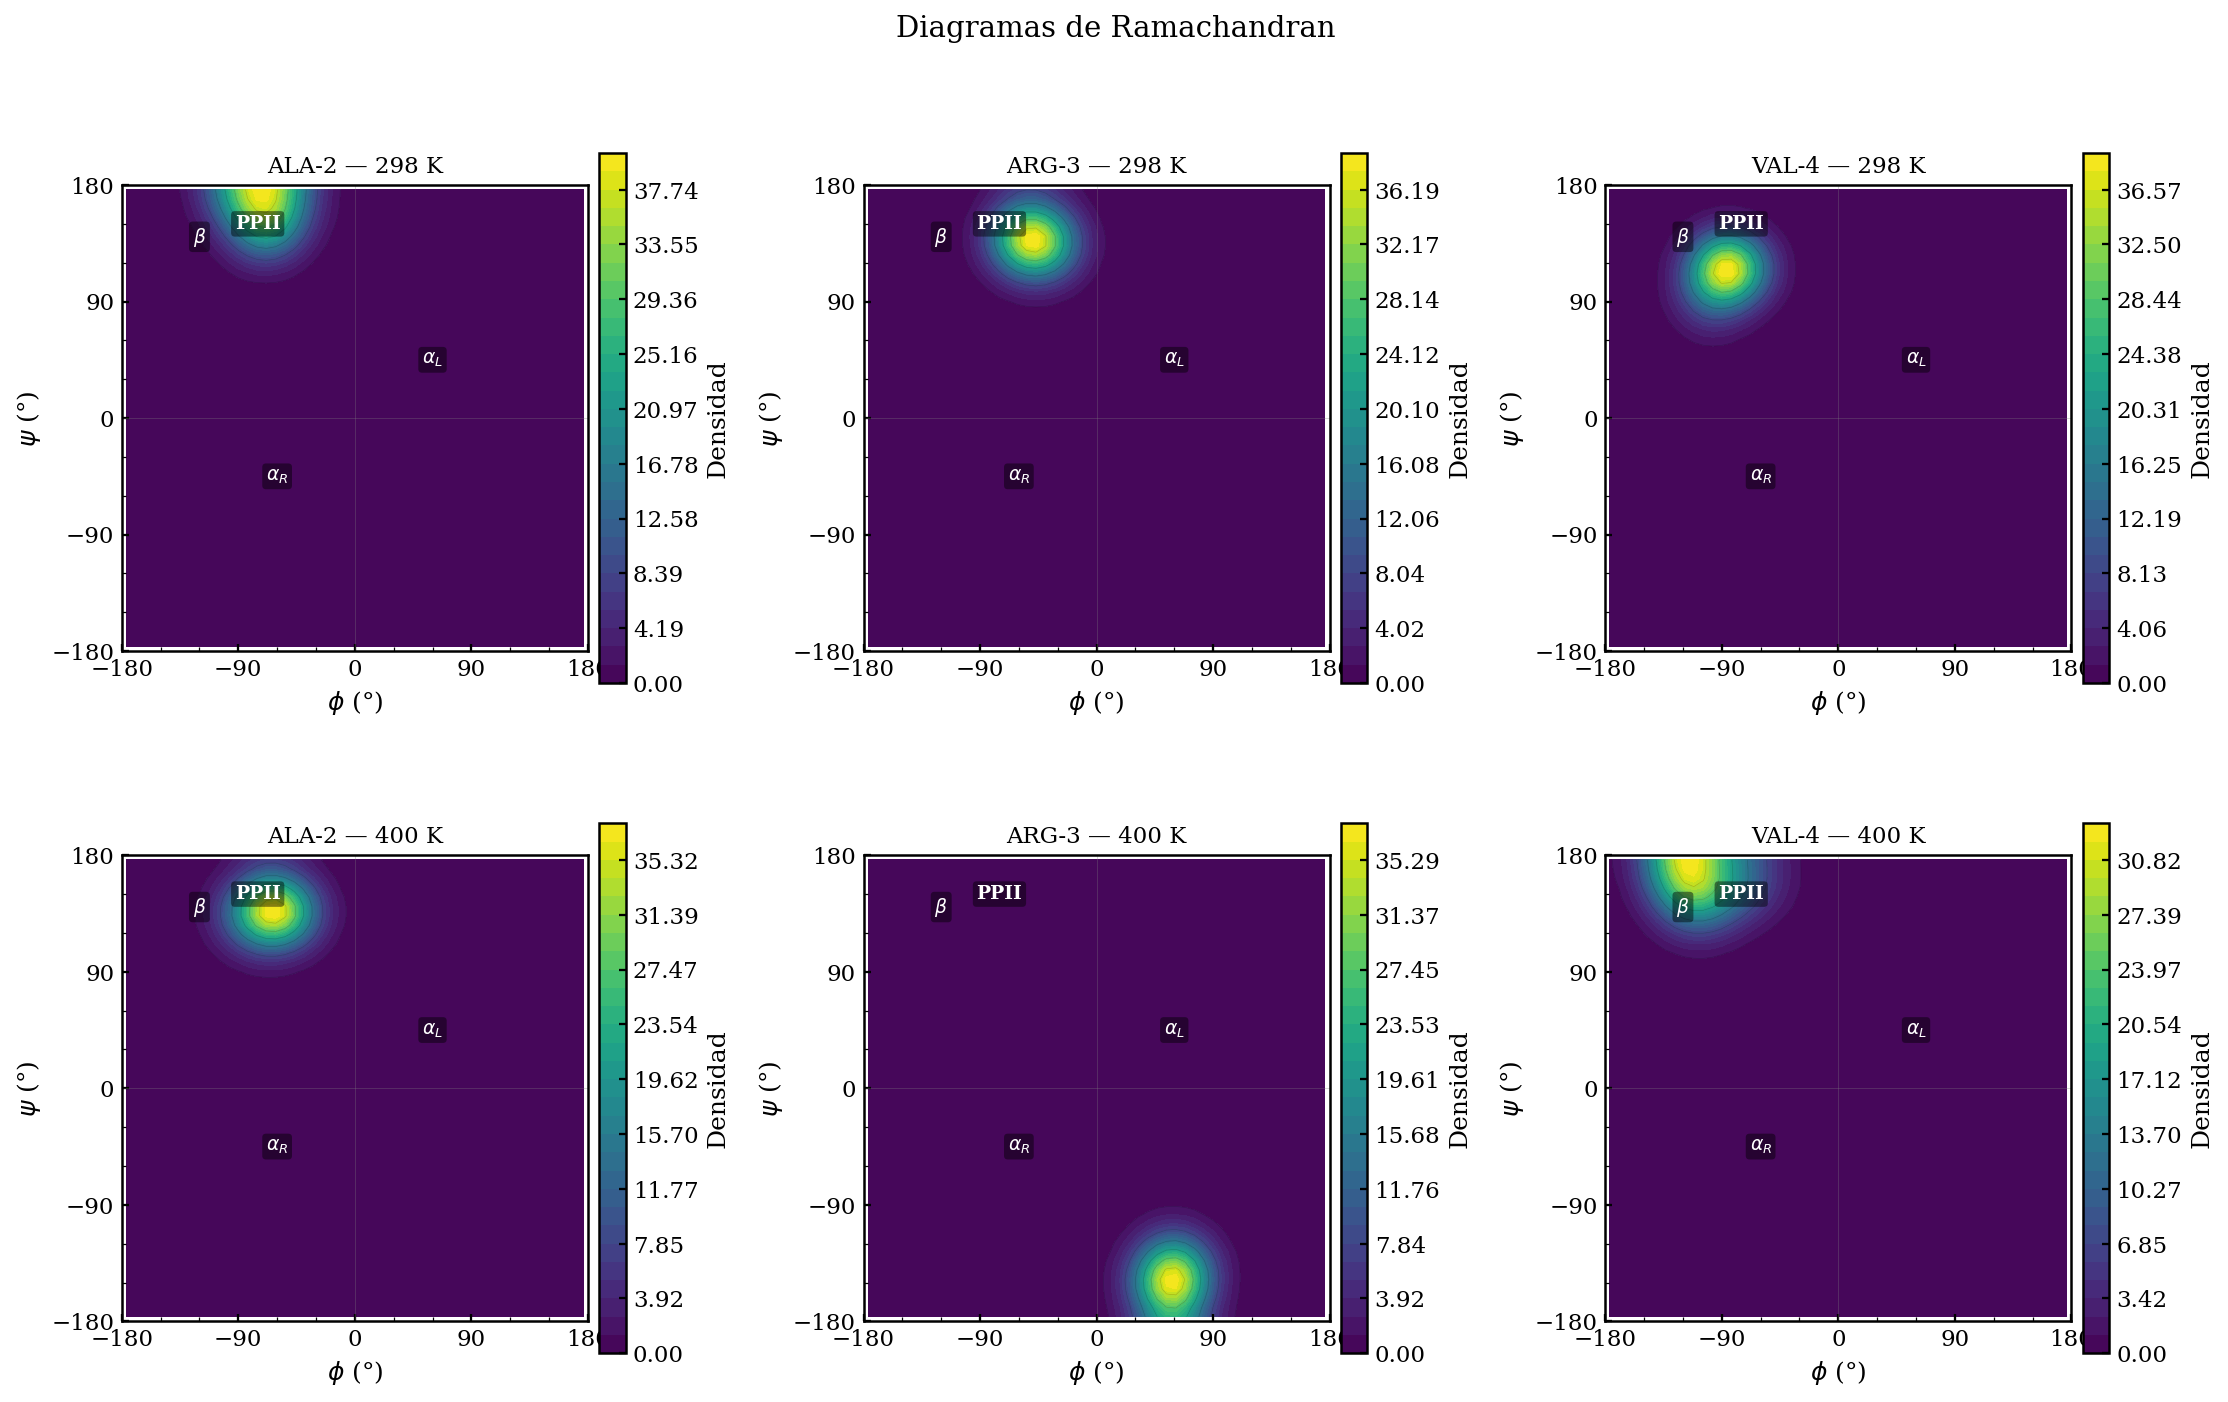

Figura guardada como ramachandran_grid.png


In [20]:
# ── Anotaciones de regiones conformacionales ──────────────────────────────────
REGIONS = [
    (-60,  -45, r'$\alpha_R$'),
    (-120, +140, r'$\beta$'),
    (+60,  +45,  r'$\alpha_L$'),
    (-75,  +150, 'PPII'),
]

residue_data = [
    ('ALA-2', df_ALA2_298, df_ALA2_400),
    ('ARG-3', df_ARG3_298, df_ARG3_400),
    ('VAL-4', df_VAL4_298, df_VAL4_400),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))

for col_ax, (res, df298, df400) in enumerate(residue_data):
    for row_ax, (df, T) in enumerate([(df298, 298), (df400, 400)]):
        ax = axes[row_ax, col_ax]
        phi_vals = df['phi'].values
        psi_vals = df['psi'].values

        # Histograma 2D suavizado con filtro Gaussiano → mapa de densidad
        H, xedges, yedges = np.histogram2d(
            phi_vals, psi_vals, bins=50,
            range=[[-180, 180], [-180, 180]])
        H = gaussian_filter(H.T, sigma=2.5)

        xcen = (xedges[:-1] + xedges[1:]) / 2
        ycen = (yedges[:-1] + yedges[1:]) / 2

        levels = np.linspace(0, H.max(), 30)
        cf = ax.contourf(xcen, ycen, H, levels=levels, cmap='viridis')
        ax.contour(xcen, ycen, H, levels=levels[1::5],
                   colors='k', linewidths=0.3, alpha=0.2)
        plt.colorbar(cf, ax=ax, label='Densidad', shrink=0.85, pad=0.02)

        # Líneas guía
        ax.axhline(0, color='gray', lw=0.5, ls='-', alpha=0.3)
        ax.axvline(0, color='gray', lw=0.5, ls='-', alpha=0.3)

        # Anotaciones de regiones
        for phi_r, psi_r, label_r in REGIONS:
            ax.annotate(label_r, xy=(phi_r, psi_r), fontsize=9,
                        color='white', ha='center', va='center', fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.2', fc='black', ec='none', alpha=0.45))

        ax.set_xlim(-180, 180)
        ax.set_ylim(-180, 180)
        ax.set_xlabel(r'$\phi$ (°)')
        ax.set_ylabel(r'$\psi$ (°)')
        ax.xaxis.set_major_locator(ticker.MultipleLocator(90))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(90))
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(30))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(30))
        ax.set_title(f'{res} — {T} K', fontsize=11)
        ax.set_aspect('equal')

fig.suptitle('Diagramas de Ramachandran', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('ramachandran_grid.png')
plt.show()
print('Figura guardada como ramachandran_grid.png')

## 11. Resumen estadístico final

In [21]:
final_rows = []
datasets = [
    ('ALA-2', 298, df_ALA2_298),
    ('ALA-2', 400, df_ALA2_400),
    ('ARG-3', 298, df_ARG3_298),
    ('ARG-3', 400, df_ARG3_400),
    ('VAL-4', 298, df_VAL4_298),
    ('VAL-4', 400, df_VAL4_400),
]

for residue, T, df in datasets:
    for ang, col in [('φ', 'phi'), ('ψ', 'psi')]:
        s = df[col]
        final_rows.append({
            'Residuo':         residue,
            'T (K)':           T,
            'Diedro':          ang,
            'N':               len(s),
            '⟨θ⟩_circ (°)':   round(circ_mean_deg(s), 2),
            'σ_circ (°)':      round(circ_std_deg(s), 2),
            'Min (°)':         round(s.min(), 2),
            'Max (°)':         round(s.max(), 2),
        })

final_df = pd.DataFrame(final_rows)

(final_df.style
    .format({
        '⟨θ⟩_circ (°)':  '{:.2f}',
        'σ_circ (°)':     '{:.2f}',
        'Min (°)':        '{:.2f}',
        'Max (°)':        '{:.2f}',
    })
    .set_caption('Tabla 1. Resumen estadístico de los ángulos diedros (estadística circular) a 298 K y 400 K.')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('margin-bottom', '6px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('text-align', 'center'), ('padding', '6px 10px'),
                   ('font-size', '12px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '5px 10px'),
                   ('font-size', '11px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f0f4f8')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#d6e4f0')]},
    ])
    .apply(lambda col: [
        'background-color: #eaf4fb' if v == 298 else 'background-color: #fdecea'
        for v in col
    ], subset=['T (K)'])
    .hide(axis='index')
)

Residuo,T (K),Diedro,N,⟨θ⟩_circ (°),σ_circ (°),Min (°),Max (°)
ALA-2,298,φ,2001,-71.35,13.96,-106.67,-39.15
ALA-2,298,ψ,2001,160.30,12.13,-179.87,179.96
ALA-2,400,φ,2001,-64.18,12.72,-101.63,-30.07
ALA-2,400,ψ,2001,136.56,6.60,117.66,159.60
ARG-3,298,φ,2001,-49.01,10.74,-75.01,-23.63
ARG-3,298,ψ,2001,137.22,7.37,116.24,154.04
ARG-3,400,φ,2001,58.46,8.69,32.38,83.98
ARG-3,400,ψ,2001,-147.87,11.57,-179.75,179.86
VAL-4,298,φ,2001,-87.19,9.69,-107.70,-61.54
VAL-4,298,ψ,2001,112.15,9.62,79.59,125.89
